In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import torch.nn.functional as F

In [2]:
words = open('names.txt','r',).read().splitlines()

building a bigram model
bigram -> only concerned with 2 characters at a time

In [ ]:
for w in words:
    for ch1, ch2 in zip(w,w[1:]):
        print(ch1,ch2)

In [3]:
w = words
list(w)
len(words)
#print(words[:10])

32033

In [4]:
#lookup table for all chars
# vocab of chars

chars =sorted(list(set(''.join(words)))) # set removes duplicates
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size =len(itos)
block_size = 3



In [5]:
# building the dataset
# we use 3 characters to predict the next 4th character
def build_dataset(words):
  block_size = 3 # context length
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
       # print(ix)
       # print(context)
        X.append(context)
        Y.append(ix)

      #  print(X)
       # print(Y)
    
       
       # print(''.join(itos[i] for i in context),'--->',itos[ix])
        context = context[1:] + [ix] # rolling context window
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 =int(0.8*len(words))
n2 =int(0.9*len(words))

#manually slicing dataset , can be done using scikit learn train_test split
Xtr, Ytr =build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2]) # validation set = 10%
Xte, Yte = build_dataset(words[n2:]) # test set = 10%



    


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
n_embed = 10 # embedding dimensions
n_hidden = 200 # nurons in hidden layer


g = torch.Generator().manual_seed(42)
C  = torch.randn((vocab_size,n_embed), generator=g)
W1 = torch.randn((block_size*n_embed,n_hidden),generator = g) # 100 neurons in the hidden layer
b1 = torch.randn(n_hidden,generator = g)
W2 = torch.randn((n_hidden,vocab_size),generator = g) # 27 neurons in the output layer
b2 = torch.randn(vocab_size, generator = g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad =  True

sum(p.nelement() for p in parameters)    

11897

In [7]:
lre =torch.linspace(-3,0,1000)
lrs = 10**lre

In [ ]:
# creating mini batches
#lri = []
#lossi = []
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):#forward pass

        #creating random batches of size 32
        ix = torch.randint(0,Xtr.shape[0],(batch_size, ),generator =g)
        Xb, Yb = Xtr[ix], Ytr[ix]# batch X, Y

        # forward pass
        emb = C[Xtr[ix]] # only grab ix rows (part of the mini batch)
        embcat = emb.view(emb.shape[0],-1) # concat the vector
        hpreact = embcat @ W1+b1
        h = torch.tanh(hpreact)
        logits = h@W2+b2
        loss = F.cross_entropy(logits, Yb)
    

        #backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        #update
        #lr = lrs[i]
        lr =  0.1 if i<100000 else 0.01 # lr decay
        for p in parameters:
            p.data+=-lr* p.grad

        # track lri and lossi
        if i%10000 ==0:
            print(f'{i:7d}/{max_steps: 7d}: {loss.item():.4f}')

        lossi.append(loss.item())          

   
    #print("lr: ",lr.item())

      0/ 200000: 2.5514
  10000/ 200000: 2.4209
  20000/ 200000: 2.1415
  30000/ 200000: 2.3441
  40000/ 200000: 2.1163
  50000/ 200000: 2.2472
  60000/ 200000: 2.1462
  70000/ 200000: 2.4223
  80000/ 200000: 2.0050
  90000/ 200000: 1.9808
 100000/ 200000: 2.2103
 110000/ 200000: 2.2720
 120000/ 200000: 2.1643
 130000/ 200000: 2.3295
 140000/ 200000: 2.1197
 150000/ 200000: 1.8432
 160000/ 200000: 2.1053
 170000/ 200000: 2.1112
 180000/ 200000: 2.3654
 190000/ 200000: 1.8967
loss:  1.980011224746704


In [ ]:
plt.plot(lossi)

In [62]:
# eval

emb = C[Xdev] # only grab ix rows (part of the mini batch)
h = torch.tanh(emb.view(-1,30)@W1 +b1)
logits = h@W2+b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.3115651607513428

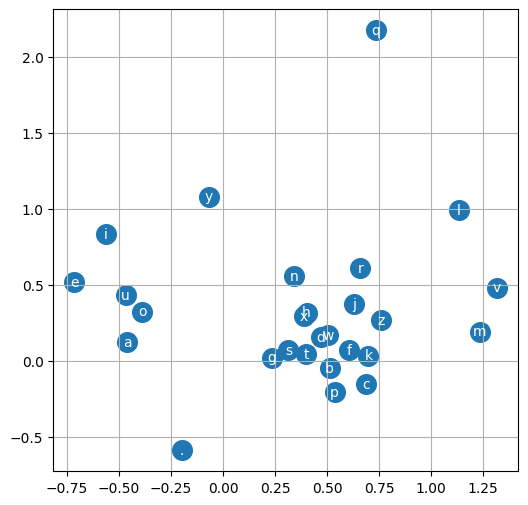

In [54]:
plt.figure(figsize=(6,6))
plt.scatter(C[:,0].data,C[:,1].data,s = 200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(),itos[i],ha ="center",va="center",color ='white')
    plt.grid('minor')


In [66]:
# sampling

g = torch.Generator().manual_seed(42)
for _ in range(20):
     out = []
     context = [0] * 3
     while True:
          emb =C[torch.tensor([context])]
          h= torch.tanh(emb.view(1,-1) @ W1 +b1)
          logits = h @ W2 +b2
          probs =F.softmax(logits, dim =1)
          ix = torch.multinomial(probs, num_samples=1, generator =g).item()
          context =context[1:] + [ix]
          out.append(ix)

          if ix ==0:
               break

     print(''.join(itos[i] for i in out)) 

anuelen.
tis.
mari.
ushanme.
samillaylen.
kemarce.
mar.
emirah.
dan.
dazi.
keel.
josey.
geddela.
marilyn.
adhvikine.
chayce.
tharlen.
jadia.
jack.
selair.


In [ ]:
# end


In [ ]:

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1

In [ ]:
itos = {i:s for s,i in stoi.items()}
itos

In [ ]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i]+itos[j]
        plt.text(j,i,chstr,ha="center",va="bottom",color = "gray")
        plt.text(j,i,N[i,j].item(),ha = "center", va  = 'top',color = 'gray')
plt.axis('off')        


In [ ]:
P = (N+1).float()
P/= P.sum(1, keepdim =True)

### building a random prob distribution, then sampling from it


In [ ]:
g=torch.Generator().manual_seed(42)
p=torch.rand(3, generator=g) # 3 rand nos from 0 to 1
p=p/p.sum() # normalize the 3 rand nos to add up to 1
p # now p is a probability vector

In [ ]:
g=torch.Generator().manual_seed(42)
p = P[0]
ix = torch.multinomial(p,1,replacement =True,generator =g).item()# sample indices from p
itos[ix]

In [ ]:
torch.multinomial(p,20,replacement =True,generator =g)# sample indices from p


In [ ]:
g=torch.Generator().manual_seed(42)
for i in range(5):

    out = []
    ix = 0 # init index at <.>

    while True:
        p = P[ix]
       
        ix = torch.multinomial(p,1,replacement =True,generator =g).item()# sampling the next character from the distribution
        out.append(itos[ix])
    
        if ix==0: # after sampling the end token end the loop
            break  
    print(''.join(out))      


In [ ]:
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2] # prob of one correct bigram
        logprob= torch.log(prob)
        log_likelihood += logprob   # likellihood of a correct word = all prob multiplied, since we use log we add
        n +=1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob: .4f}')
        nll = -log_likelihood # lower is better
print(f'{log_likelihood=}')  
print(f'{nll=}')
print(f'{nll/n=}')      

### creating training set of all the bigrams


In [ ]:
xs , ys = [],[] # inputs and targets
# input is the current char, target is the next char(sucessive)
for w in words:
    chs = ['.']+list(w)+['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num =  xs.nelement()
print("number of exampels: ",num)

In [ ]:
xenc = F.one_hot(xs, num_classes = 27).float() # using one hot encoding to feed vectors to nn
xenc.shape
plt.imshow(xenc)

In [ ]:
# rand init of weights of 27 neurons
# each neuron 27 inputs

g = torch.Generator().manual_seed(42)
W = torch.randn((27,27),generator = g)


In [ ]:
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims = True)

nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()

    print("--------")
    print(f"bigram example {i+1}:{itos[x]}{itos[y]}   (indexes {x}, {y})")
    print("input to the neural net: ",x)
    print("output prob from the neural net: ",probs[i])
    print("label (actual next character): ",y)
    p=probs[i,y]
    print("prob assigned to the correct char: ",p.item())
    logp = torch.log(p)
    print("log_likelihood",logp.item())
    nll = -logp
    print("negative log log_likelihood: ",nll.item())
    nlls[i] = nll
    print("---------")
    print("average negative log log_likelihood, ie loss",nlls.mean().item())



In [ ]:
# rand init of weights of 27 neurons
# each neuron 27 inputs

g = torch.Generator().manual_seed(42)
W = torch.randn((27,27),generator = g, requires_grad=True)


In [ ]:
# regularization 
(W**2).mean()

In [ ]:
# gradient descent
for k in range(100):
    # forwards pass

    xenc = F.one_hot(xs, num_classes = 27).float()
    logits = (xenc @ W)  # raw scores
    #softmax
    counts = logits.exp()# counts are now positive log counts
    probs = counts / counts.sum(1, keepdims = True)  # normalize the counts to prob distri.
    loss =  -probs[torch.arange(num),ys].log().mean() + 0.01*(W**2).mean()# for only first 5 birgrams -> first words ".emma."
    print(loss.item())

        # backward pass
    W.grad = None # set grad to 0 for init
    loss.backward()

    # update W
    W.data += -50*W.grad





In [ ]:
# sampling from neural net model
g = torch.Generator().manual_seed(42)
for i in range(5):
     out = []
     ix = 0
     while True:
         xenc = F.one_hot(torch.tensor([ix]), num_classes = 27).float()
         logits = xenc @ W
         counts = logits.exp()
         p = counts / counts.sum(1, keepdims = True)
         ix = torch.multinomial(p[0],num_samples = 1,replacement = True, generator=g).item()
         out.append(itos[ix])
         if ix ==0:
            break
     print(''.join(out))